<a href="https://colab.research.google.com/github/UKD1211/DataScience_Slogbook_ISI_placement_prep/blob/main/prob_dist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import random

In [2]:
L = []
for i in range(10000):
  L.append(random.randint(1,6))

In [3]:
len(L)

10000

In [4]:
L[:5]

[5, 1, 5, 2, 3]

In [5]:
a = pd.Series(L)

In [6]:
a

,0
0,5
1,1
2,5
3,2
4,3
...,...
9995,4
9996,5
9997,6
9998,2


In [7]:
s = (a.value_counts()/a.value_counts().sum()).sort_index()

In [8]:
s

,count
1,0.1629
2,0.1612
3,0.1664
4,0.1667
5,0.1692
6,0.1736


<Axes: >

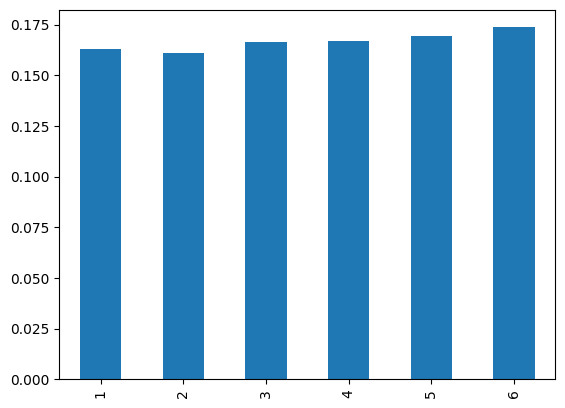

In [9]:
s.plot(kind = 'bar')

In [10]:
new_l= []
for i in range(10000):
  a = random.randint(1,6)
  b = random.randint(1,6)
  new_l.append(a+b)

In [11]:
new_l[:5]

[8, 8, 5, 6, 8]

In [12]:
x = pd.Series(new_l)

In [13]:
x

,0
0,8
1,8
2,5
3,6
4,8
...,...
9995,7
9996,8
9997,2
9998,4


<Axes: >

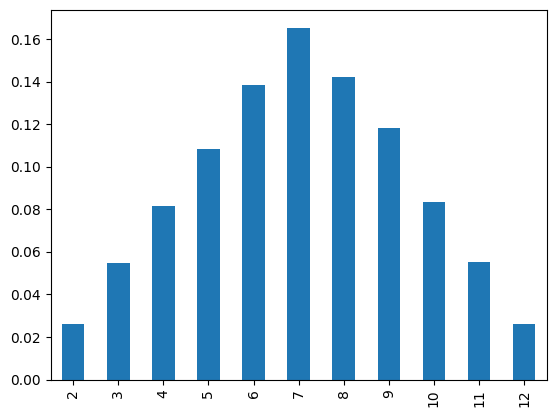

In [14]:
(x.value_counts()/x.value_counts().sum()).sort_index().plot(kind='bar')

In [15]:
s = (x.value_counts()/x.value_counts().sum()).sort_index()

In [16]:
np.cumsum(s)  #cdf #by cumsum

,count
2,0.0263
3,0.0811
4,0.1628
5,0.2709
6,0.4092
7,0.5746
8,0.7168
9,0.8348
10,0.9184
11,0.9737


<Axes: >

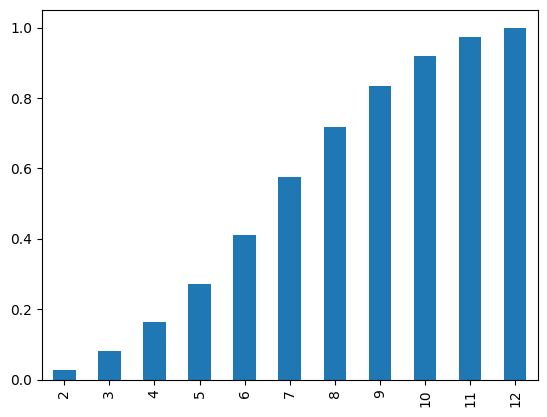

In [17]:
np.cumsum(s).plot(kind = 'bar')

# Parametric Density Estimation

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal

sample = normal(loc=50, scale=5,size=1000) #pop parameters

In [19]:
sample.mean()

np.float64(50.040093010766505)

(array([  5.,   9.,  49., 135., 206., 276., 201.,  87.,  25.,   7.]),
 array([32.02562059, 35.43124758, 38.83687458, 42.24250157, 45.64812856,
        49.05375555, 52.45938255, 55.86500954, 59.27063653, 62.67626353,
        66.08189052]),
 <BarContainer object of 10 artists>)

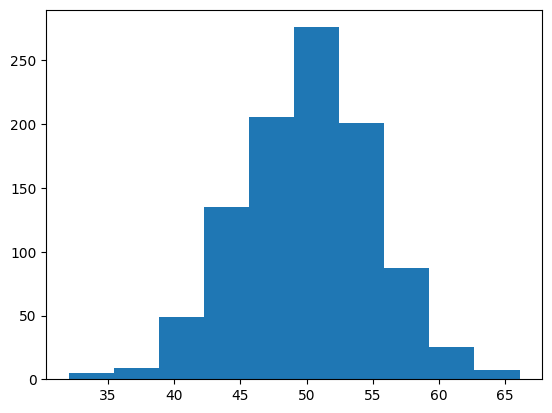

In [20]:
plt.hist(sample,bins=10)

In [21]:
sample_mean = sample.mean()
sample_std = sample.std()

In [22]:
# fit the distribution with the above parameters

from scipy.stats import norm
dist = norm(60, 12)

In [23]:
values = np.linspace(sample.min(),sample.max(),100)

In [24]:
sample.min()

np.float64(32.02562058951354)

In [25]:
sample.max()

np.float64(66.08189052024714)

In [26]:
probabilities = [dist.pdf(value) for value in values]  #probdensities

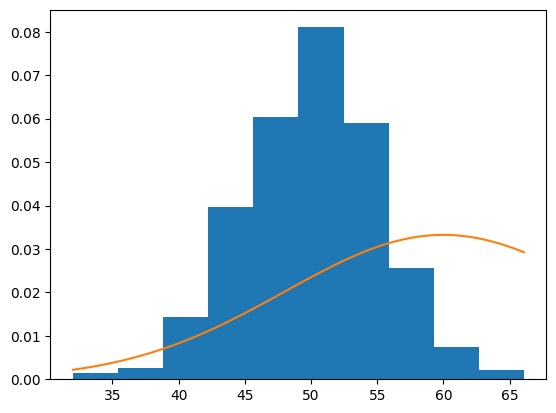

In [27]:
plt.hist(sample,bins = 10,density = True)
plt.plot(values,probabilities)

/tmp/ipython-input-1482356190.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

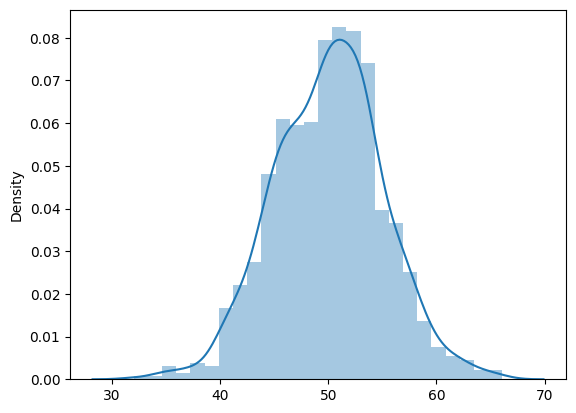

In [28]:
import seaborn as sns
sns.distplot(sample)

# **KDE**

In [38]:
# generate a sample
sample1 = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1, sample2))

In [39]:
sample

array([22.83326556, 23.75193339, 24.16373868, 19.04447358, 23.66871849,
       20.56368571, 20.06935906, 16.92448167, 27.07366164, 11.96824596,
       13.72779456, 26.86751247, 17.08499988, 17.97092579, 23.28877476,
       14.63415836, 21.27152305, 20.48212338,  9.06939454, 17.12886415,
       21.90872028, 13.78684138, 29.26173668, 15.93726864, 19.52843255,
       22.68731339, 13.71957004, 26.75756828, 27.0651745 , 20.04095795,
       20.73419252, 19.89216405, 27.24565396, 19.76829382, 17.74710277,
       24.14765925, 10.12716098, 26.11230023,  8.59263753, 18.79989899,
       20.55782234, 14.20380908, 23.16645008, 22.34325855, 20.39649062,
       19.43540112, 16.71172448, 26.47511021, 20.23784737, 19.3082896 ,
       20.51749366, 24.59851496, 19.20003091, 21.39140685, 11.97614571,
       18.100062  , 28.25099108, 12.15635281, 23.39191305, 15.29181612,
       12.27167634, 27.95225845, 24.13481054, 18.69400722, 24.91629157,
       21.21722978, 14.24178554, 11.8673782 , 19.41462218, 19.47

(array([ 1.,  0.,  0.,  2.,  3.,  2.,  5.,  8.,  8., 21., 15., 13., 19.,
        23., 29., 27., 20., 17., 24., 15., 11., 12., 12., 11.,  6., 18.,
        20., 23., 33., 38., 24., 41., 42., 57., 60., 55., 71., 44., 40.,
        37., 30., 20., 20.,  9.,  8.,  1.,  3.,  1.,  0.,  1.]),
 array([ 4.1267366 ,  5.16520798,  6.20367937,  7.24215075,  8.28062213,
         9.31909351, 10.3575649 , 11.39603628, 12.43450766, 13.47297904,
        14.51145042, 15.54992181, 16.58839319, 17.62686457, 18.66533595,
        19.70380734, 20.74227872, 21.7807501 , 22.81922148, 23.85769286,
        24.89616425, 25.93463563, 26.97310701, 28.01157839, 29.05004978,
        30.08852116, 31.12699254, 32.16546392, 33.20393531, 34.24240669,
        35.28087807, 36.31934945, 37.35782083, 38.39629222, 39.4347636 ,
        40.47323498, 41.51170636, 42.55017775, 43.58864913, 44.62712051,
        45.66559189, 46.70406327, 47.74253466, 48.78100604, 49.81947742,
        50.8579488 , 51.89642019, 52.93489157, 53.97336295,

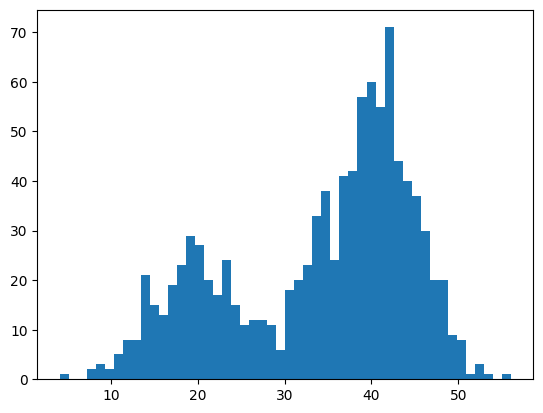

In [40]:
#plot hist
plt.hist(sample,bins=50)

In [49]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(kernel='gaussian', bandwidth=3)  #gaussian is the most used one, bandwidth = std

#data should be 1d -> 2d
sample = sample.reshape((len(sample), 1))

# fit the distribution
model.fit(sample)

KernelDensity(bandwidth=3)

In [50]:
values = np.linspace(sample.min(),sample.max(),100)
values = values.reshape((len(values), 1))

In [51]:
probabilities = model.score_samples(values)
probabilities = np.exp(probabilities)   #it gives us the log densities for us

`score_samples(values)` returns the log-density estimate of the input samples values. This is because the `score_samples()` method of the KernelDensity class returns the logarithm of the probability density estimate rather than the actual probability density estimate.

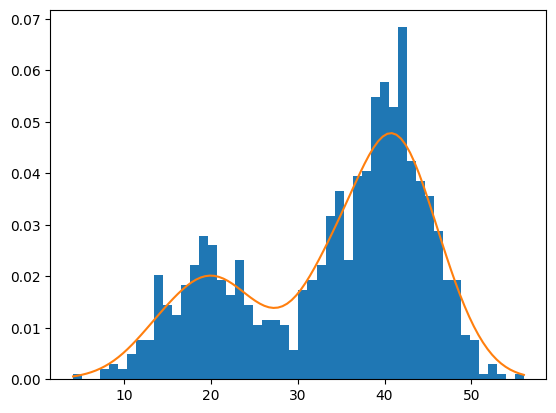

In [52]:
plt.hist(sample, bins=50, density=True)
plt.plot(values[:], probabilities)
plt.show()